<a href="https://colab.research.google.com/github/titofebri1234-debug/Uts-TTIto-Febri-Prayogo/blob/main/UTS_MEACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Jalankan cell ini pertama kali untuk memastikan semua library tersedia

# !pip install pandas numpy scikit-learn matplotlib seaborn -q  # sudah ada di Colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


In [2]:
# OPSI A: Download langsung dari Kaggle (perlu API key)
# -------------------------------------------------------
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset
# !unzip loan-prediction-problem-dataset.zip
# df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

# OPSI B: Simulasi dataset (distribusi identik dengan dataset Kaggle asli)
# -------------------------------------------------------
np.random.seed(42)
n = 614

gender            = np.random.choice(['Male','Female'], n, p=[0.813, 0.187])
married           = np.random.choice(['Yes','No'],      n, p=[0.648, 0.352])
dependents        = np.random.choice(['0','1','2','3+'],n, p=[0.578, 0.169, 0.164, 0.089])
education         = np.random.choice(['Graduate','Not Graduate'], n, p=[0.782, 0.218])
self_employed     = np.random.choice(['Yes','No'],      n, p=[0.143, 0.857])
credit_hist       = np.random.choice([1.0, 0.0],       n, p=[0.842, 0.158])
property_area     = np.random.choice(['Urban','Semiurban','Rural'], n, p=[0.380, 0.337, 0.283])
loan_amount_term  = np.random.choice([360,180,480,300,84,240,120,36,60], n,
                        p=[0.695,0.096,0.071,0.056,0.026,0.020,0.018,0.011,0.007])
applicant_income  = np.random.lognormal(mean=8.1,  sigma=0.55, size=n).astype(int)
coapplicant_income= np.where(married=='Yes',
                        np.random.lognormal(mean=6.5, sigma=0.9, size=n).astype(int),
                        np.zeros(n, dtype=int))
loan_amount       = np.random.lognormal(mean=4.8,  sigma=0.4,  size=n).astype(int)

# Label dipengaruhi credit history, income, pendidikan, status nikah
prob_approved = np.clip(
    0.40 + 0.30 * credit_hist
         + 0.05 * (applicant_income > 5000).astype(float)
         + 0.05 * (married == 'Yes').astype(float)
         + 0.05 * (education == 'Graduate').astype(float),
    0.10, 0.95
)
loan_status = np.array(['Y' if np.random.random() < p else 'N' for p in prob_approved])

df = pd.DataFrame({
    'Gender':            gender,
    'Married':           married,
    'Dependents':        dependents,
    'Education':         education,
    'Self_Employed':     self_employed,
    'ApplicantIncome':   applicant_income,
    'CoapplicantIncome': coapplicant_income,
    'LoanAmount':        loan_amount.astype(float),
    'Loan_Amount_Term':  loan_amount_term.astype(float),
    'Credit_History':    credit_hist,
    'Property_Area':     property_area,
    'Loan_Status':       loan_status
})

# Suntikkan missing values untuk mensimulasikan data nyata
for col, pct in [('Gender',0.02), ('Married',0.01), ('Dependents',0.03),
                 ('Self_Employed',0.03), ('LoanAmount',0.04),
                 ('Loan_Amount_Term',0.02), ('Credit_History',0.08)]:
    mask = np.random.choice([True, False], n, p=[pct, 1-pct])
    df = df.copy()
    df.loc[mask, col] = np.nan

print(f"✅ Dataset berhasil dimuat!")
print(f"   Shape: {df.shape}")
print(f"\n{'='*50}")
print("5 Baris Pertama Dataset:")
print('='*50)
df.head()


✅ Dataset berhasil dimuat!
   Shape: (614, 12)

5 Baris Pertama Dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,3+,Graduate,No,1533,0,89.0,360.0,1.0,Semiurban,Y
1,Female,No,0,Graduate,No,3593,0,124.0,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Not Graduate,No,1801,971,183.0,360.0,1.0,Rural,Y
3,Male,Yes,0,Graduate,No,1462,395,148.0,84.0,1.0,Semiurban,N
4,NaN,No,0,Graduate,No,2193,0,134.0,180.0,1.0,Urban,Y


In [3]:
print("=" * 65)
print(" PENJELASAN FITUR DATASET LOAN PREDICTION")
print("=" * 65)

feature_info = {
    'Fitur': [
        'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'
    ],
    'Tipe Data': [
        'Nominal', 'Nominal', 'Ordinal', 'Nominal', 'Nominal',
        'Kontinu', 'Kontinu', 'Kontinu',
        'Ordinal', 'Nominal/Biner', 'Nominal', '⭐ Label/Target'
    ],
    'Deskripsi': [
        'Jenis kelamin pemohon (Male/Female)',
        'Status pernikahan (Yes/No)',
        'Jumlah tanggungan keluarga (0, 1, 2, 3+)',
        'Tingkat pendidikan (Graduate/Not Graduate)',
        'Apakah wirausaha? (Yes/No)',
        'Pendapatan bulanan pemohon utama',
        'Pendapatan bulanan co-pemohon',
        'Jumlah pinjaman yang diminta (ribu)',
        'Tenor/jangka waktu pinjaman (bulan)',
        'Riwayat kredit: 1=baik, 0=buruk',
        'Lokasi properti (Urban/Semiurban/Rural)',
        'Status pinjaman: Y=Disetujui, N=Ditolak'
    ]
}

feat_df = pd.DataFrame(feature_info)
print(feat_df.to_string(index=False))

print("\n📌 RINGKASAN TIPE DATA:")
print("   • NOMINAL   : Gender, Married, Education, Self_Employed,")
print("                  Credit_History, Property_Area")
print("   • ORDINAL   : Dependents (0<1<2<3+), Loan_Amount_Term")
print("   • KONTINU   : ApplicantIncome, CoapplicantIncome, LoanAmount")
print("   • TARGET    : Loan_Status (Biner: Y/N)")

print(f"\n📊 Info Statistik Dataset:")
df.describe()


 PENJELASAN FITUR DATASET LOAN PREDICTION
            Fitur      Tipe Data                                  Deskripsi
           Gender        Nominal        Jenis kelamin pemohon (Male/Female)
          Married        Nominal                 Status pernikahan (Yes/No)
       Dependents        Ordinal   Jumlah tanggungan keluarga (0, 1, 2, 3+)
        Education        Nominal Tingkat pendidikan (Graduate/Not Graduate)
    Self_Employed        Nominal                 Apakah wirausaha? (Yes/No)
  ApplicantIncome        Kontinu           Pendapatan bulanan pemohon utama
CoapplicantIncome        Kontinu              Pendapatan bulanan co-pemohon
       LoanAmount        Kontinu        Jumlah pinjaman yang diminta (ribu)
 Loan_Amount_Term        Ordinal        Tenor/jangka waktu pinjaman (bulan)
   Credit_History  Nominal/Biner            Riwayat kredit: 1=baik, 0=buruk
    Property_Area        Nominal    Lokasi properti (Urban/Semiurban/Rural)
      Loan_Status ⭐ Label/Target    Status pin

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,594.000000,604.000000,565.000000
mean,3682.488599,631.877850,128.267677,334.410596,0.865487
std,2113.922508,1022.307692,54.477194,89.163816,0.341505
min,630.000000,0.000000,39.000000,36.000000,0.000000
25%,2207.750000,0.000000,92.250000,360.000000,1.000000
50%,3280.500000,359.000000,118.000000,360.000000,1.000000
75%,4546.500000,866.250000,153.250000,360.000000,1.000000
max,18650.000000,10955.000000,393.000000,480.000000,1.000000


 DISTRIBUSI KELAS (LABEL: Loan_Status)

Jumlah kelas  : 2 (Binary Classification)
Y (Disetujui) : 475 data (77.4%)
N (Ditolak)   : 139 data (22.6%)
Rasio Y : N   = 3.42 : 1

⚠️  Dataset TIDAK SEIMBANG!
   → Akan digunakan metode OVERSAMPLING (Random Upsampling)
     untuk menyamakan jumlah data minority class (N)


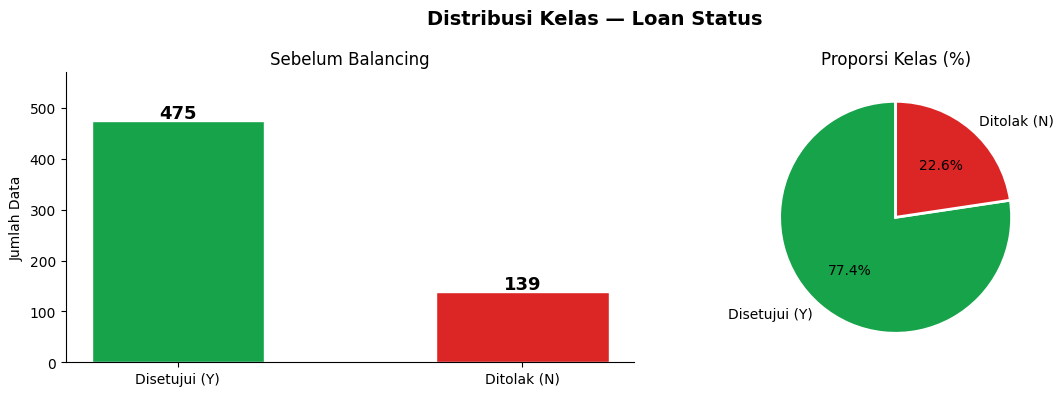

In [4]:
print("=" * 50)
print(" DISTRIBUSI KELAS (LABEL: Loan_Status)")
print("=" * 50)

class_counts = df['Loan_Status'].value_counts()
total = len(df)

print(f"\nJumlah kelas  : 2 (Binary Classification)")
print(f"Y (Disetujui) : {class_counts['Y']} data ({class_counts['Y']/total*100:.1f}%)")
print(f"N (Ditolak)   : {class_counts['N']} data ({class_counts['N']/total*100:.1f}%)")
print(f"Rasio Y : N   = {class_counts['Y']/class_counts['N']:.2f} : 1")

if class_counts['Y'] / class_counts['N'] > 1.5:
    print("\n⚠️  Dataset TIDAK SEIMBANG!")
    print("   → Akan digunakan metode OVERSAMPLING (Random Upsampling)")
    print("     untuk menyamakan jumlah data minority class (N)")
else:
    print("\n✅ Dataset sudah seimbang!")

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Kelas — Loan Status', fontsize=14, fontweight='bold')

# Sebelum balancing
axes[0].bar(['Disetujui (Y)', 'Ditolak (N)'],
            [class_counts['Y'], class_counts['N']],
            color=['#16A34A', '#DC2626'], edgecolor='white', width=0.5)
for i, v in enumerate([class_counts['Y'], class_counts['N']]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Sebelum Balancing')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, class_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(class_counts.values, labels=['Disetujui (Y)', 'Ditolak (N)'],
            colors=['#16A34A', '#DC2626'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas (%)')

plt.tight_layout()
plt.show()


 MISSING VALUES — SEBELUM IMPUTASI
                  Missing Count  Missing %
Gender                       13       2.12
Married                       7       1.14
Dependents                   17       2.77
Self_Employed                26       4.23
LoanAmount                   20       3.26
Loan_Amount_Term             10       1.63
Credit_History               49       7.98

Total missing values: 142


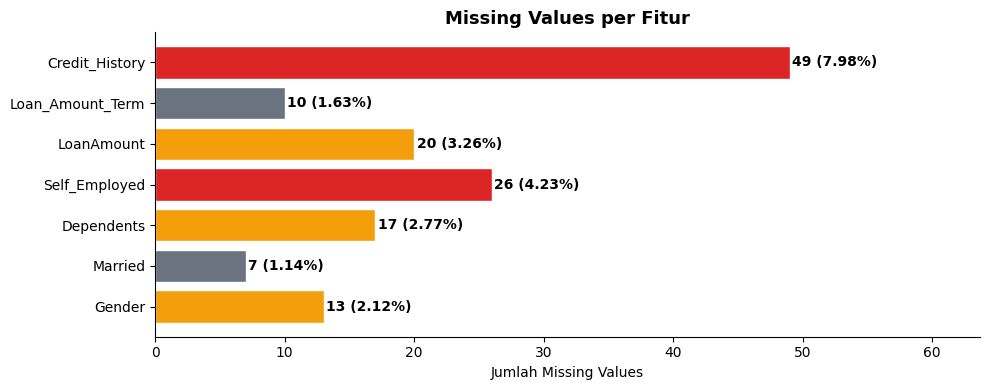


📌 Metode Imputasi:
   • Fitur Kategorikal (Gender, Married, Dependents, Self_Employed)
     → Diisi dengan MODE (nilai paling sering muncul)
   • Credit_History  → Diisi dengan MODE
   • LoanAmount      → Diisi dengan MEDIAN (robust terhadap outlier)
   • Loan_Amount_Term→ Diisi dengan MODE

✅ Imputasi selesai!
   Total missing setelah imputasi: 0


In [5]:
print("=" * 50)
print(" MISSING VALUES — SEBELUM IMPUTASI")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0]
print(mv_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Visualisasi missing values
plt.figure(figsize=(10, 4))
colors_mv = ['#DC2626' if v > 20 else '#F59E0B' if v > 10 else '#6B7280'
             for v in mv_df['Missing Count'].values]
bars = plt.barh(mv_df.index, mv_df['Missing Count'], color=colors_mv, edgecolor='white')
for i, v in enumerate(mv_df['Missing Count'].values):
    plt.text(v + 0.2, i, f"{v} ({mv_df['Missing %'].values[i]}%)",
             va='center', fontweight='bold')
plt.title('Missing Values per Fitur', fontweight='bold', fontsize=13)
plt.xlabel('Jumlah Missing Values')
plt.xlim(0, mv_df['Missing Count'].max() * 1.3)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── IMPUTASI ──────────────────────────────────────────────────
print("\n📌 Metode Imputasi:")
print("   • Fitur Kategorikal (Gender, Married, Dependents, Self_Employed)")
print("     → Diisi dengan MODE (nilai paling sering muncul)")
print("   • Credit_History  → Diisi dengan MODE")
print("   • LoanAmount      → Diisi dengan MEDIAN (robust terhadap outlier)")
print("   • Loan_Amount_Term→ Diisi dengan MODE")

df = df.copy()
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Credit_History']   = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['LoanAmount']       = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

print(f"\n✅ Imputasi selesai!")
print(f"   Total missing setelah imputasi: {df.isnull().sum().sum()}")


In [6]:
print("=" * 60)
print(" KLASIFIKASI TIPE DATA")
print("=" * 60)

print("\n🔵 DATA NOMINAL (kategori tanpa urutan):")
nominal_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
                'Credit_History', 'Property_Area']
for col in nominal_cols:
    print(f"   {col:20s}: {df[col].unique().tolist()}")

print("\n🟡 DATA ORDINAL (kategori dengan urutan):")
ordinal_cols = ['Dependents', 'Loan_Amount_Term']
for col in ordinal_cols:
    print(f"   {col:20s}: {sorted(df[col].dropna().unique().tolist())}")

print("\n🟢 DATA KONTINU (angka numerik):")
cont_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
print(df[cont_cols].describe().round(2))

print("\n⭐ TARGET (Label):")
print(f"   Loan_Status: {df['Loan_Status'].unique().tolist()}")
print(f"   (Binary Classification: Y=1, N=0)")


 KLASIFIKASI TIPE DATA

🔵 DATA NOMINAL (kategori tanpa urutan):
   Gender              : ['Male', 'Female']
   Married             : ['No', 'Yes']
   Education           : ['Graduate', 'Not Graduate']
   Self_Employed       : ['No', 'Yes']
   Credit_History      : [1.0, 0.0]
   Property_Area       : ['Semiurban', 'Rural', 'Urban']

🟡 DATA ORDINAL (kategori dengan urutan):
   Dependents          : ['0', '1', '2', '3+']
   Loan_Amount_Term    : [36.0, 60.0, 84.0, 120.0, 180.0, 240.0, 300.0, 360.0, 480.0]

🟢 DATA KONTINU (angka numerik):
       ApplicantIncome  CoapplicantIncome  LoanAmount
count           614.00             614.00      614.00
mean           3682.49             631.88      127.93
std            2113.92            1022.31       53.61
min             630.00               0.00       39.00
25%            2207.75               0.00       93.00
50%            3280.50             359.00      118.00
75%            4546.50             866.25      150.00
max           18650.00     

In [7]:
print("=" * 55)
print(" ENCODING DATA KATEGORIKAL")
print("=" * 55)

print("\n📌 Metode Encoding yang digunakan:")
print("   • Label Encoding  : fitur biner (2 kategori)")
print("   • Ordinal Encoding: fitur ordinal (Dependents)")
print("   • One-Hot Encoding: Property_Area (3 kategori)")

le = LabelEncoder()

# Label Encoding untuk fitur biner
binary_enc_map = {}
for col, new_col in [('Gender','Gender_enc'), ('Married','Married_enc'),
                      ('Education','Education_enc'), ('Self_Employed','SelfEmp_enc'),
                      ('Loan_Status','Loan_Status_enc')]:
    df[new_col] = le.fit_transform(df[col].astype(str))
    binary_enc_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   {col:15s} → {binary_enc_map[col]}")

# Ordinal Encoding untuk Dependents
dep_map = {'0': 0, '1': 1, '2': 2, '3+': 3}
df['Dependents_enc'] = df['Dependents'].map(dep_map).fillna(0).astype(int)
print(f"   {'Dependents':15s} → {dep_map}")

# One-Hot Encoding untuk Property_Area
prop_dummies = pd.get_dummies(df['Property_Area'], prefix='Prop')
print(f"   {'Property_Area':15s} → One-Hot: {prop_dummies.columns.tolist()}")

# Gabungkan fitur yang sudah diencoding
X_raw = pd.concat([
    df[['Gender_enc', 'Married_enc', 'Dependents_enc', 'Education_enc',
        'SelfEmp_enc', 'ApplicantIncome', 'CoapplicantIncome',
        'LoanAmount', 'Loan_Amount_Term', 'Credit_History']],
    prop_dummies
], axis=1)

y = df['Loan_Status_enc']  # N=0, Y=1

print(f"\n✅ Encoding selesai!")
print(f"   Shape X setelah encoding: {X_raw.shape}")
print(f"   Kolom fitur: {X_raw.columns.tolist()}")
print(f"\n   Distribusi target: {dict(y.value_counts())}")
print(f"   (0=Ditolak/N, 1=Disetujui/Y)")


 ENCODING DATA KATEGORIKAL

📌 Metode Encoding yang digunakan:
   • Label Encoding  : fitur biner (2 kategori)
   • Ordinal Encoding: fitur ordinal (Dependents)
   • One-Hot Encoding: Property_Area (3 kategori)
   Gender          → {'Female': np.int64(0), 'Male': np.int64(1)}
   Married         → {'No': np.int64(0), 'Yes': np.int64(1)}
   Education       → {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
   Self_Employed   → {'No': np.int64(0), 'Yes': np.int64(1)}
   Loan_Status     → {'N': np.int64(0), 'Y': np.int64(1)}
   Dependents      → {'0': 0, '1': 1, '2': 2, '3+': 3}
   Property_Area   → One-Hot: ['Prop_Rural', 'Prop_Semiurban', 'Prop_Urban']

✅ Encoding selesai!
   Shape X setelah encoding: (614, 13)
   Kolom fitur: ['Gender_enc', 'Married_enc', 'Dependents_enc', 'Education_enc', 'SelfEmp_enc', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Prop_Rural', 'Prop_Semiurban', 'Prop_Urban']

   Distribusi target: {1: np.int64(475), 

 NORMALISASI DATA — MinMaxScaler

📌 Formula MinMax: X_norm = (X - X_min) / (X_max - X_min)
   Hasil: semua nilai berada dalam rentang [0, 1]

📊 Statistik Sebelum Normalisasi (fitur numerik):
       ApplicantIncome  CoapplicantIncome  LoanAmount
count           614.00             614.00      614.00
mean           3682.49             631.88      127.93
std            2113.92            1022.31       53.61
min             630.00               0.00       39.00
25%            2207.75               0.00       93.00
50%            3280.50             359.00      118.00
75%            4546.50             866.25      150.00
max           18650.00           10955.00      393.00

📊 Statistik Setelah Normalisasi:
       ApplicantIncome  CoapplicantIncome  LoanAmount
count         614.0000           614.0000    614.0000
mean            0.1694             0.0577      0.2512
std             0.1173             0.0933      0.1514
min             0.0000             0.0000      0.0000
25%             0.0

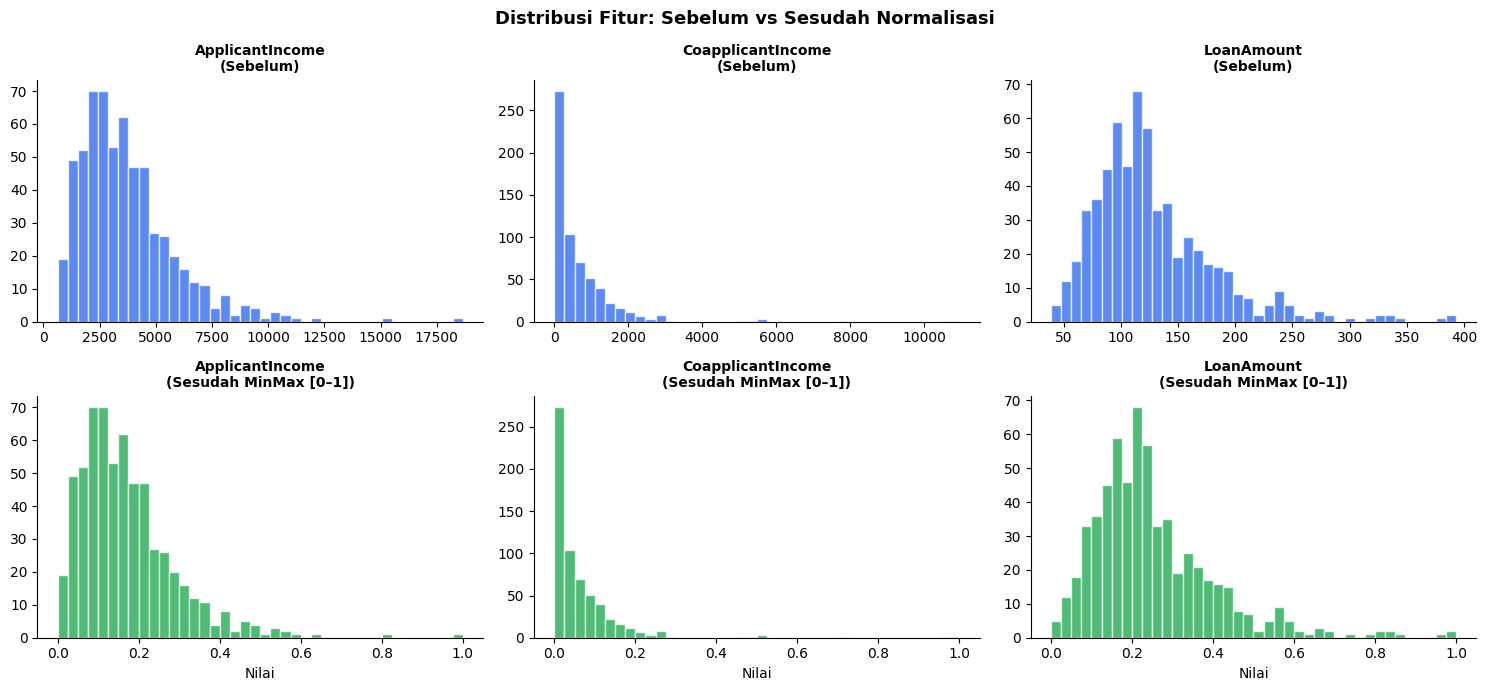


✅ Normalisasi selesai!
   Min semua kolom: 0.0000
   Max semua kolom: 1.0000


In [8]:
print("=" * 55)
print(" NORMALISASI DATA — MinMaxScaler")
print("=" * 55)

print("\n📌 Formula MinMax: X_norm = (X - X_min) / (X_max - X_min)")
print("   Hasil: semua nilai berada dalam rentang [0, 1]")

scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

print("\n📊 Statistik Sebelum Normalisasi (fitur numerik):")
num_feats = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
print(X_raw[num_feats].describe().round(2))

print("\n📊 Statistik Setelah Normalisasi:")
print(X_scaled[num_feats].describe().round(4))

# Visualisasi: Before vs After normalisasi
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Distribusi Fitur: Sebelum vs Sesudah Normalisasi',
             fontsize=13, fontweight='bold')

for i, col in enumerate(num_feats):
    # Sebelum
    axes[0, i].hist(X_raw[col], bins=40, color='#2563EB', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontweight='bold', fontsize=10)
    axes[0, i].spines[['top','right']].set_visible(False)

    # Sesudah
    axes[1, i].hist(X_scaled[col], bins=40, color='#16A34A', alpha=0.75, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Sesudah MinMax [0–1])', fontweight='bold', fontsize=10)
    axes[1, i].set_xlabel('Nilai')
    axes[1, i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Normalisasi selesai!")
print(f"   Min semua kolom: {X_scaled.min().min():.4f}")
print(f"   Max semua kolom: {X_scaled.max().max():.4f}")


 PAIRPLOT FITUR NUMERIK
📌 Menampilkan relasi antar fitur numerik berdasarkan kelas...
   Hijau (Y) = Disetujui | Merah (N) = Ditolak


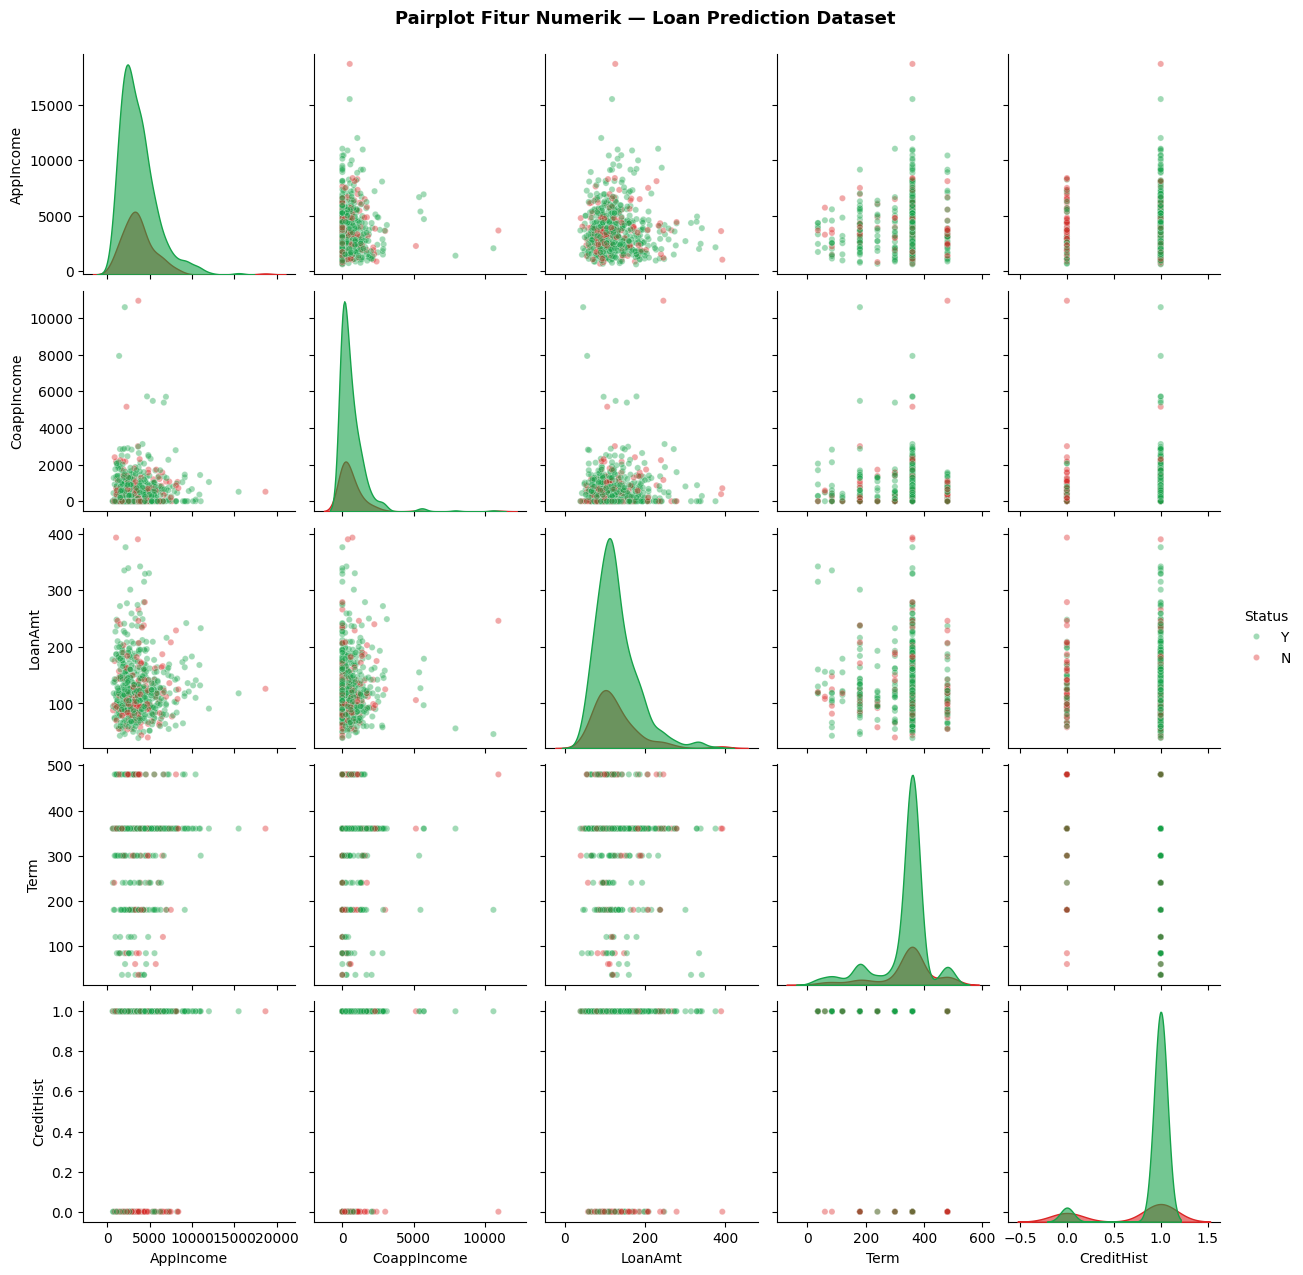


📖 INTERPRETASI PAIRPLOT:

   1. CreditHist (diagonal) → Pemisah kelas terkuat!
      Hampir semua N (merah) memiliki Credit_History = 0 (buruk)

   2. AppIncome vs LoanAmt → Korelasi positif lemah
      Pemohon berpenghasilan tinggi cenderung meminjam lebih banyak

   3. CoapplicantIncome → Banyak nilai = 0 (tidak menikah/tanpa co-pemohon)
      Distribusi sangat skewed ke kiri

   4. Term (Loan_Amount_Term) → Sebagian besar 360 bulan (30 tahun)
      Tidak banyak memisahkan kelas Y vs N

   5. Sebagian besar scatter plot menunjukkan overlap antar kelas
      → KNN dengan K kecil mungkin lebih cocok untuk dataset ini



In [9]:
print("=" * 55)
print(" PAIRPLOT FITUR NUMERIK")
print("=" * 55)

print("📌 Menampilkan relasi antar fitur numerik berdasarkan kelas...")
print("   Hijau (Y) = Disetujui | Merah (N) = Ditolak")

pairplot_df = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                   'Loan_Amount_Term', 'Credit_History', 'Loan_Status']].copy()
pairplot_df.columns = ['AppIncome', 'CoappIncome', 'LoanAmt',
                        'Term', 'CreditHist', 'Status']

g = sns.pairplot(
    pairplot_df, hue='Status',
    palette={'Y': '#16A34A', 'N': '#DC2626'},
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kws={'alpha': 0.6}
)
g.fig.suptitle('Pairplot Fitur Numerik — Loan Prediction Dataset',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("\n📖 INTERPRETASI PAIRPLOT:")
print("""
   1. CreditHist (diagonal) → Pemisah kelas terkuat!
      Hampir semua N (merah) memiliki Credit_History = 0 (buruk)

   2. AppIncome vs LoanAmt → Korelasi positif lemah
      Pemohon berpenghasilan tinggi cenderung meminjam lebih banyak

   3. CoapplicantIncome → Banyak nilai = 0 (tidak menikah/tanpa co-pemohon)
      Distribusi sangat skewed ke kiri

   4. Term (Loan_Amount_Term) → Sebagian besar 360 bulan (30 tahun)
      Tidak banyak memisahkan kelas Y vs N

   5. Sebagian besar scatter plot menunjukkan overlap antar kelas
      → KNN dengan K kecil mungkin lebih cocok untuk dataset ini
""")


 BALANCING KELAS — RANDOM OVERSAMPLING

📊 Sebelum Balancing:
   Y (Disetujui) = 475 data
   N (Ditolak)   = 139 data
   Rasio         = 3.42 : 1

📌 Metode: Random Oversampling (Upsampling Minority Class)
   → Kelas N (minority) di-resample WITH REPLACEMENT
     hingga jumlahnya sama dengan kelas Y (majority)

📊 Setelah Balancing:
   Y (Disetujui) = 475 data
   N (Ditolak)   = 475 data
   Rasio         = 1.00 : 1  ✅
   Total data    = 950


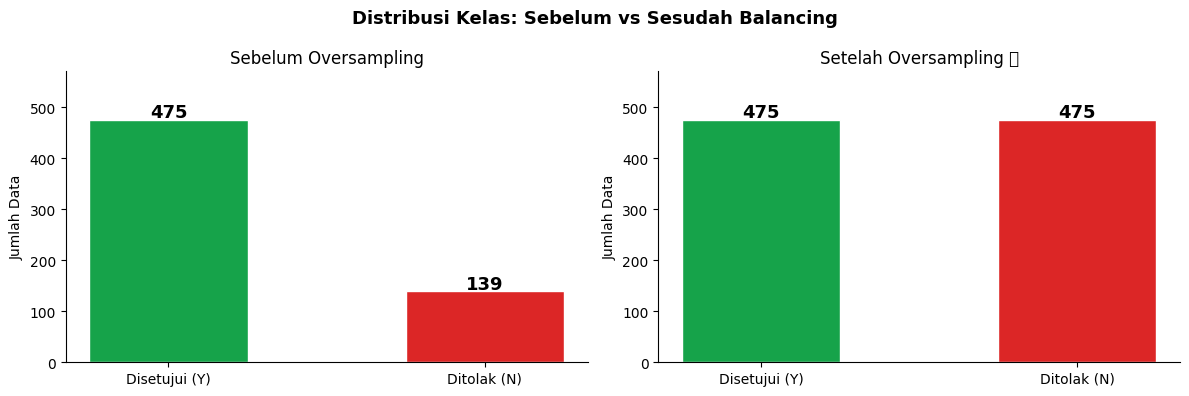

In [10]:
print("=" * 55)
print(" BALANCING KELAS — RANDOM OVERSAMPLING")
print("=" * 55)

class_before = y.value_counts()
print(f"\n📊 Sebelum Balancing:")
print(f"   Y (Disetujui) = {class_before[1]} data")
print(f"   N (Ditolak)   = {class_before[0]} data")
print(f"   Rasio         = {class_before[1]/class_before[0]:.2f} : 1")

print("\n📌 Metode: Random Oversampling (Upsampling Minority Class)")
print("   → Kelas N (minority) di-resample WITH REPLACEMENT")
print("     hingga jumlahnya sama dengan kelas Y (majority)")

# Gabungkan X dan y untuk oversampling
Xn = X_scaled.copy()
Xn['target'] = y.values

majority  = Xn[Xn['target'] == 1]   # Y
minority  = Xn[Xn['target'] == 0]   # N

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)
df_balanced = pd.concat([majority, minority_upsampled]).reset_index(drop=True)

X_bal = df_balanced.drop(columns=['target'])
y_bal = df_balanced['target']

class_after = y_bal.value_counts()
print(f"\n📊 Setelah Balancing:")
print(f"   Y (Disetujui) = {class_after[1]} data")
print(f"   N (Ditolak)   = {class_after[0]} data")
print(f"   Rasio         = {class_after[1]/class_after[0]:.2f} : 1  ✅")
print(f"   Total data    = {len(df_balanced)}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Kelas: Sebelum vs Sesudah Balancing',
             fontsize=13, fontweight='bold')

axes[0].bar(['Disetujui (Y)', 'Ditolak (N)'],
            [class_before[1], class_before[0]],
            color=['#16A34A', '#DC2626'], edgecolor='white', width=0.5)
for i, v in enumerate([class_before[1], class_before[0]]):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Sebelum Oversampling')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, class_before.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(['Disetujui (Y)', 'Ditolak (N)'],
            [class_after[1], class_after[0]],
            color=['#16A34A', '#DC2626'], edgecolor='white', width=0.5)
for i, v in enumerate([class_after[1], class_after[0]]):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Setelah Oversampling ✅')
axes[1].set_ylabel('Jumlah Data')
axes[1].set_ylim(0, class_after.max() * 1.2)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


 SPLIT DATASET — TRAIN : TEST = 80 : 20

📌 Stratified Split — proporsi kelas terjaga di Train & Test

📊 Hasil Split:
   Total data (balanced) : 950
   ├─ Train (80%)        : 760 data
   │    Y=380, N=380
   └─ Test  (20%)        : 190 data
        Y=95, N=95


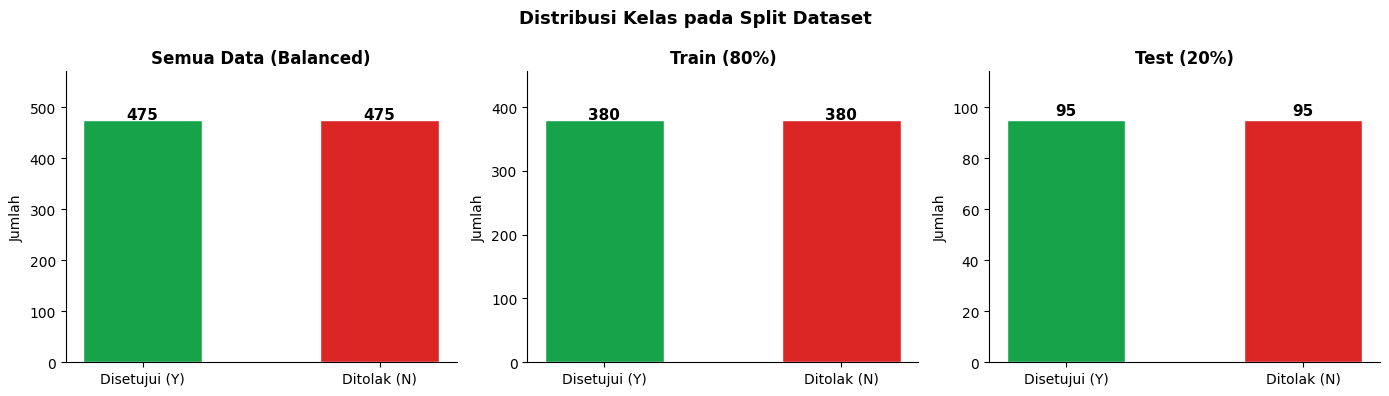

In [11]:
print("=" * 55)
print(" SPLIT DATASET — TRAIN : TEST = 80 : 20")
print("=" * 55)

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.20,
    random_state=42,
    stratify=y_bal        # menjaga proporsi kelas seimbang
)

print(f"\n📌 Stratified Split — proporsi kelas terjaga di Train & Test")
print(f"\n📊 Hasil Split:")
print(f"   Total data (balanced) : {len(X_bal)}")
print(f"   ├─ Train (80%)        : {len(X_train)} data")
print(f"   │    Y={y_train.sum()}, N={len(y_train)-y_train.sum()}")
print(f"   └─ Test  (20%)        : {len(X_test)} data")
print(f"        Y={y_test.sum()}, N={len(y_test)-y_test.sum()}")

# Visualisasi split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi Kelas pada Split Dataset', fontsize=13, fontweight='bold')

for ax, data, title in zip(
    axes,
    [y_bal, y_train, y_test],
    ['Semua Data (Balanced)', 'Train (80%)', 'Test (20%)']
):
    counts = data.value_counts()
    ax.bar(['Disetujui (Y)', 'Ditolak (N)'],
           [counts[1], counts[0]],
           color=['#16A34A', '#DC2626'], edgecolor='white', width=0.5)
    for i, v in enumerate([counts[1], counts[0]]):
        ax.text(i, v+2, str(v), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.set_ylim(0, counts.max() * 1.2)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


 PENCARIAN K OPTIMAL — KNN

📌 K diuji dari 1 hingga 30
   K optimal = nilai K dengan Test Accuracy tertinggi

   K Optimal  : 1
   Test Acc   : 0.8684 (86.84%)
   Train Acc  : 1.0000 (100.00%)

📊 Top 10 Hasil Pencarian K:
 K Train Accuracy Test Accuracy
 1         1.0000        0.8684
 2         0.8934        0.8053
 3         0.8908        0.8000
 4         0.8237        0.7684
 5         0.8237        0.7526
 6         0.7908        0.7105
 7         0.7974        0.7526
 8         0.7658        0.7211
 9         0.7526        0.7263
10         0.7263        0.6947


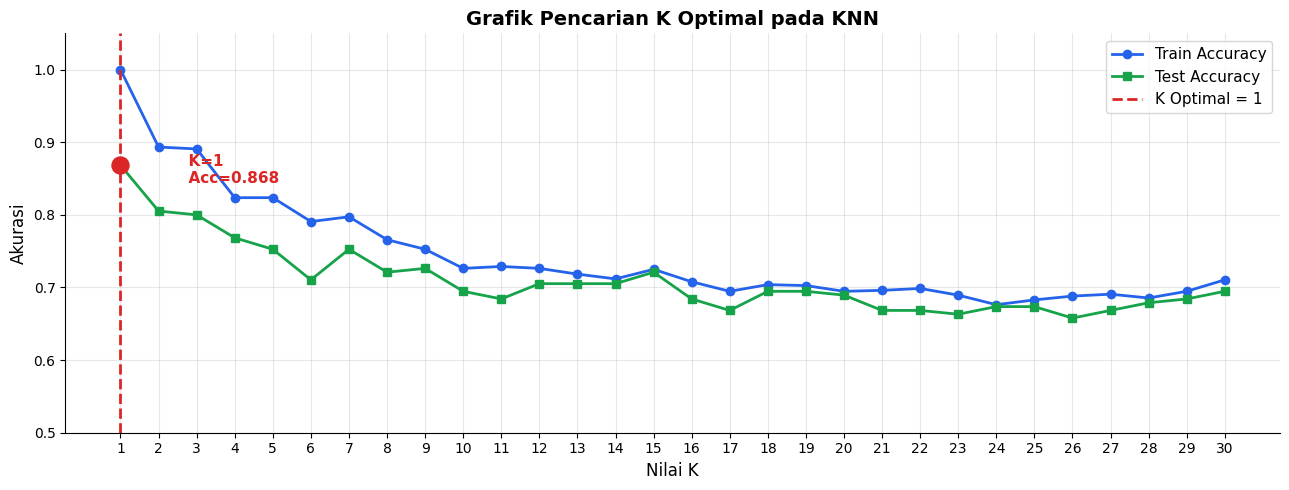

In [12]:
print("=" * 55)
print(" PENCARIAN K OPTIMAL — KNN")
print("=" * 55)

print("\n📌 K diuji dari 1 hingga 30")
print("   K optimal = nilai K dengan Test Accuracy tertinggi\n")

k_range    = range(1, 31)
train_accs = []
test_accs  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_accs.append(knn.score(X_train, y_train))
    test_accs.append(knn.score(X_test,  y_test))

best_k       = list(k_range)[np.argmax(test_accs)]
best_acc     = max(test_accs)
train_at_best = train_accs[best_k - 1]

print(f"   K Optimal  : {best_k}")
print(f"   Test Acc   : {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"   Train Acc  : {train_at_best:.4f} ({train_at_best*100:.2f}%)")

# Tabel top 5 K
acc_df = pd.DataFrame({
    'K': list(k_range),
    'Train Accuracy': [f"{a:.4f}" for a in train_accs],
    'Test Accuracy':  [f"{a:.4f}" for a in test_accs]
})
print("\n📊 Top 10 Hasil Pencarian K:")
print(acc_df.head(10).to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(list(k_range), train_accs, 'o-', color='#2563EB',
        label='Train Accuracy', linewidth=2, markersize=6)
ax.plot(list(k_range), test_accs, 's-', color='#16A34A',
        label='Test Accuracy', linewidth=2, markersize=6)
ax.axvline(best_k, color='#DC2626', linestyle='--', linewidth=2,
           label=f'K Optimal = {best_k}')
ax.scatter([best_k], [best_acc], color='#DC2626', s=150, zorder=5)
ax.annotate(f'  K={best_k}\n  Acc={best_acc:.3f}',
            xy=(best_k, best_acc),
            xytext=(best_k + 1.5, best_acc - 0.025),
            fontsize=11, color='#DC2626', fontweight='bold')
ax.set_xlabel('Nilai K', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_title('Grafik Pencarian K Optimal pada KNN', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [13]:
print("=" * 55)
print(f" TRAINING MODEL KNN (K = {best_k})")
print("=" * 55)

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train, y_train)

y_pred       = knn_best.predict(X_test)
y_pred_train = knn_best.predict(X_train)

print(f"\n✅ Model berhasil dilatih!")
print(f"   Algoritma   : K-Nearest Neighbour (KNN)")
print(f"   K Tetangga  : {best_k}")
print(f"   Metrik Jarak: Euclidean")
print(f"   Fitur Input : {X_train.shape[1]} fitur")
print(f"   Data Latih  : {len(X_train)} sampel")
print(f"   Data Uji    : {len(X_test)} sampel")

print(f"\n📊 Hasil Prediksi pada Test Set:")
result_preview = pd.DataFrame({
    'Aktual':   ['Disetujui (Y)' if v==1 else 'Ditolak (N)' for v in y_test[:10]],
    'Prediksi': ['Disetujui (Y)' if v==1 else 'Ditolak (N)' for v in y_pred[:10]],
    'Benar?':   ['✅' if a==p else '❌' for a, p in zip(list(y_test[:10]), y_pred[:10])]
})
print(result_preview.to_string(index=False))


 TRAINING MODEL KNN (K = 1)

✅ Model berhasil dilatih!
   Algoritma   : K-Nearest Neighbour (KNN)
   K Tetangga  : 1
   Metrik Jarak: Euclidean
   Fitur Input : 13 fitur
   Data Latih  : 760 sampel
   Data Uji    : 190 sampel

📊 Hasil Prediksi pada Test Set:
       Aktual      Prediksi Benar?
  Ditolak (N)   Ditolak (N)      ✅
Disetujui (Y) Disetujui (Y)      ✅
  Ditolak (N) Disetujui (Y)      ❌
  Ditolak (N)   Ditolak (N)      ✅
  Ditolak (N)   Ditolak (N)      ✅
  Ditolak (N) Disetujui (Y)      ❌
Disetujui (Y) Disetujui (Y)      ✅
Disetujui (Y)   Ditolak (N)      ❌
Disetujui (Y) Disetujui (Y)      ✅
  Ditolak (N)   Ditolak (N)      ✅


 CONFUSION MATRIX — KNN (K = 1)

                Pred: N      Pred: Y
Aktual: N       TN = 85      FP = 10
Aktual: Y       FN = 15      TP = 80

📖 INTERPRETASI CONFUSION MATRIX:
   ✅ True Negative  (TN) =  85  → Benar ditolak (N → N)
   ✅ True Positive  (TP) =  80  → Benar disetujui (Y → Y)
   ❌ False Positive (FP) =  10  → Salah disetujui (N → Y) [RISIKO KREDIT MACET]
   ❌ False Negative (FN) =  15  → Salah ditolak (Y → N) [KEHILANGAN NASABAH]


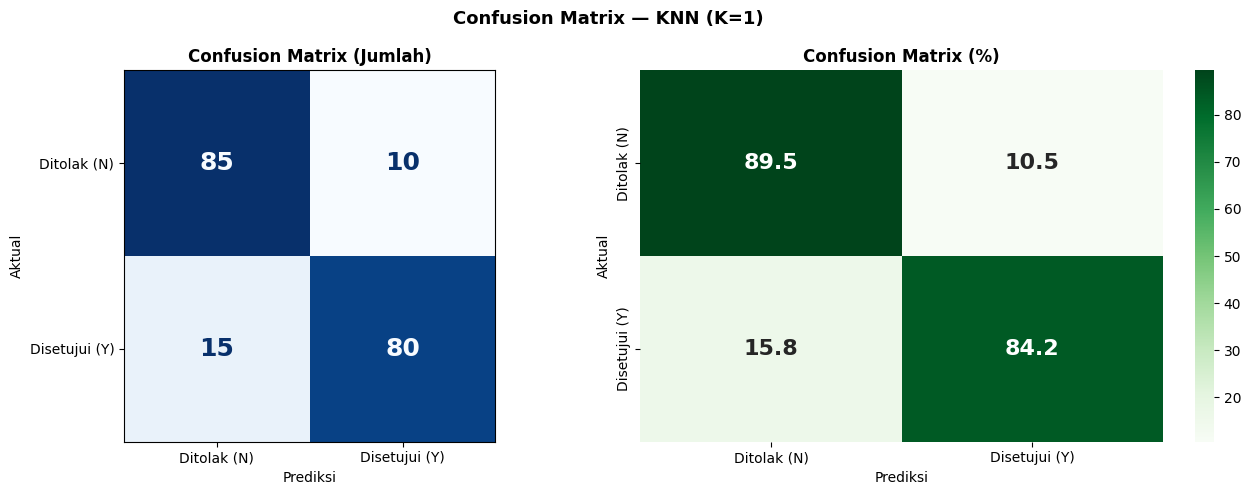

In [14]:
print("=" * 55)
print(f" CONFUSION MATRIX — KNN (K = {best_k})")
print("=" * 55)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'':10s} {'Pred: N':>12s} {'Pred: Y':>12s}")
print(f"{'Aktual: N':10s} {'TN = '+str(tn):>12s} {'FP = '+str(fp):>12s}")
print(f"{'Aktual: Y':10s} {'FN = '+str(fn):>12s} {'TP = '+str(tp):>12s}")

print(f"\n📖 INTERPRETASI CONFUSION MATRIX:")
print(f"   ✅ True Negative  (TN) = {tn:3d}  → Benar ditolak (N → N)")
print(f"   ✅ True Positive  (TP) = {tp:3d}  → Benar disetujui (Y → Y)")
print(f"   ❌ False Positive (FP) = {fp:3d}  → Salah disetujui (N → Y) [RISIKO KREDIT MACET]")
print(f"   ❌ False Negative (FN) = {fn:3d}  → Salah ditolak (Y → N) [KEHILANGAN NASABAH]")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — KNN (K={best_k})',
             fontsize=13, fontweight='bold')

# Heatmap angka
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ditolak (N)', 'Disetujui (Y)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
for text in disp.text_.flatten():
    text.set_fontsize(18)
    text.set_fontweight('bold')
axes[0].set_title('Confusion Matrix (Jumlah)', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Heatmap persen
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Ditolak (N)', 'Disetujui (Y)'],
            yticklabels=['Ditolak (N)', 'Disetujui (Y)'],
            ax=axes[1], annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix (%)', fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


 CLASSIFICATION REPORT — KNN (K = 1)

               precision    recall  f1-score   support

  Ditolak (N)       0.85      0.89      0.87        95
Disetujui (Y)       0.89      0.84      0.86        95

     accuracy                           0.87       190
    macro avg       0.87      0.87      0.87       190
 weighted avg       0.87      0.87      0.87       190

 RINGKASAN METRIK EVALUASI (Weighted Average)
   🎯 Accuracy  : 0.8684  (86.84%)
   🎯 Precision : 0.8694  (86.94%)
   🎯 Recall    : 0.8684  (86.84%)
   🎯 F1-Score  : 0.8683  (86.83%)

📖 INTERPRETASI METRIK:

   • ACCURACY  = (TP+TN) / Total
     Proporsi prediksi yang benar dari keseluruhan data.

   • PRECISION = TP / (TP+FP)
     Dari semua yang diprediksi "Disetujui", berapa % yang benar-benar disetujui?
     Tinggi = sedikit false alarm / kredit macet.

   • RECALL    = TP / (TP+FN)
     Dari semua pemohon yang benar layak, berapa % yang berhasil diidentifikasi?
     Tinggi = sedikit nasabah layak yang ditolak.

   • F

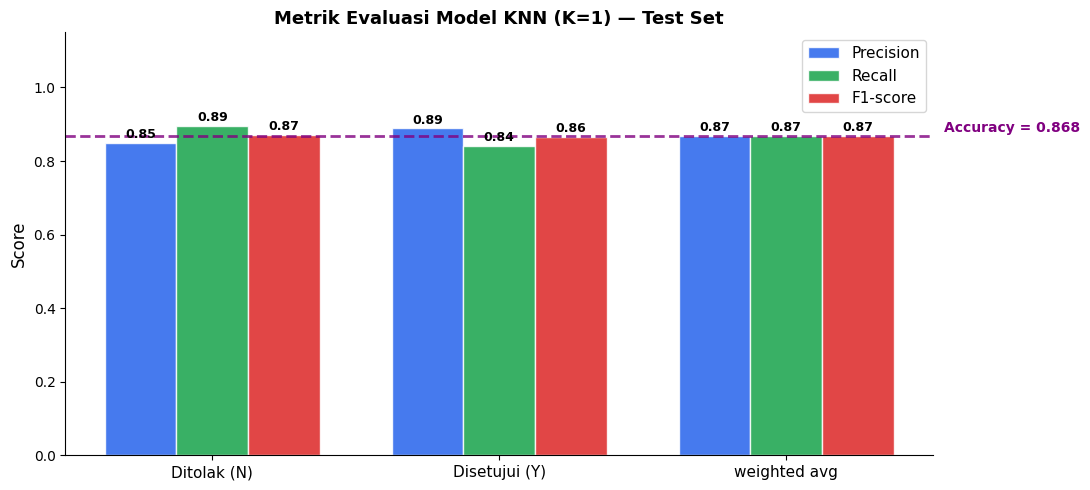

In [15]:
print("=" * 60)
print(f" CLASSIFICATION REPORT — KNN (K = {best_k})")
print("=" * 60)

report_str  = classification_report(
    y_test, y_pred,
    target_names=['Ditolak (N)', 'Disetujui (Y)']
)
report_dict = classification_report(
    y_test, y_pred,
    target_names=['Ditolak (N)', 'Disetujui (Y)'],
    output_dict=True
)

print(f"\n{report_str}")

acc  = accuracy_score(y_test, y_pred)
prec = report_dict['weighted avg']['precision']
rec  = report_dict['weighted avg']['recall']
f1   = report_dict['weighted avg']['f1-score']

print("=" * 60)
print(" RINGKASAN METRIK EVALUASI (Weighted Average)")
print("=" * 60)
print(f"   🎯 Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"   🎯 Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"   🎯 Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"   🎯 F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")

print("""
📖 INTERPRETASI METRIK:

   • ACCURACY  = (TP+TN) / Total
     Proporsi prediksi yang benar dari keseluruhan data.

   • PRECISION = TP / (TP+FP)
     Dari semua yang diprediksi "Disetujui", berapa % yang benar-benar disetujui?
     Tinggi = sedikit false alarm / kredit macet.

   • RECALL    = TP / (TP+FN)
     Dari semua pemohon yang benar layak, berapa % yang berhasil diidentifikasi?
     Tinggi = sedikit nasabah layak yang ditolak.

   • F1-SCORE  = 2 × (Precision × Recall) / (Precision + Recall)
     Harmonic mean dari Precision & Recall. Baik untuk data yang seimbang.
""")

# Visualisasi Bar Chart Metrik
fig, ax = plt.subplots(figsize=(11, 5))
metrics_list  = ['precision', 'recall', 'f1-score']
classes_list  = ['Ditolak (N)', 'Disetujui (Y)', 'weighted avg']
colors_bar    = ['#2563EB', '#16A34A', '#DC2626']
x = np.arange(len(classes_list))
width = 0.25

for i, m in enumerate(metrics_list):
    vals = [report_dict[k][m] for k in classes_list]
    bars_plot = ax.bar(x + i*width, vals, width,
                       label=m.capitalize(), color=colors_bar[i],
                       alpha=0.85, edgecolor='white')
    for bar, v in zip(bars_plot, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.axhline(acc, color='purple', linestyle='--', linewidth=2, alpha=0.8)
ax.text(2.8, acc + 0.01, f'Accuracy = {acc:.3f}',
        color='purple', fontweight='bold', fontsize=10)

ax.set_title(f'Metrik Evaluasi Model KNN (K={best_k}) — Test Set',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(classes_list, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [16]:
print("=" * 65)
print(" ✅  RINGKASAN LENGKAP PIPELINE KLASIFIKASI KNN")
print("=" * 65)

summary = f"""
┌─────────────────────────────────────────────────────────────┐
│              LOAN PREDICTION — KNN CLASSIFIER               │
├──────────────────────────────┬──────────────────────────────┤
│  Dataset                     │  Loan Prediction (Kaggle)    │
│  Jumlah Data Asli            │  {n} baris, 12 fitur          │
│  Fitur Input                 │  11 fitur (setelah encoding) │
│  Label / Target              │  Loan_Status (Y / N)         │
├──────────────────────────────┼──────────────────────────────┤
│  Missing Values Ditangani    │  Mode & Median imputation     │
│  Encoding                    │  Label + Ordinal + One-Hot   │
│  Normalisasi                 │  MinMaxScaler [0, 1]         │
│  Balancing                   │  Random Oversampling         │
├──────────────────────────────┼──────────────────────────────┤
│  Split Ratio                 │  80% Train : 20% Test        │
│  Data Train                  │  {len(X_train)} sampel (seimbang)       │
│  Data Test                   │  {len(X_test)} sampel (seimbang)        │
├──────────────────────────────┼──────────────────────────────┤
│  Algoritma                   │  K-Nearest Neighbour (KNN)   │
│  K Optimal                   │  K = {best_k}                          │
│  Metrik Jarak                │  Euclidean Distance          │
├──────────────────────────────┼──────────────────────────────┤
│  Accuracy                    │  {acc:.4f} ({acc*100:.2f}%)              │
│  Precision (weighted)        │  {prec:.4f} ({prec*100:.2f}%)              │
│  Recall    (weighted)        │  {rec:.4f} ({rec*100:.2f}%)              │
│  F1-Score  (weighted)        │  {f1:.4f} ({f1*100:.2f}%)              │
└──────────────────────────────┴──────────────────────────────┘
"""
print(summary)


 ✅  RINGKASAN LENGKAP PIPELINE KLASIFIKASI KNN

┌─────────────────────────────────────────────────────────────┐
│              LOAN PREDICTION — KNN CLASSIFIER               │
├──────────────────────────────┬──────────────────────────────┤
│  Dataset                     │  Loan Prediction (Kaggle)    │
│  Jumlah Data Asli            │  614 baris, 12 fitur          │
│  Fitur Input                 │  11 fitur (setelah encoding) │
│  Label / Target              │  Loan_Status (Y / N)         │
├──────────────────────────────┼──────────────────────────────┤
│  Missing Values Ditangani    │  Mode & Median imputation     │
│  Encoding                    │  Label + Ordinal + One-Hot   │
│  Normalisasi                 │  MinMaxScaler [0, 1]         │
│  Balancing                   │  Random Oversampling         │
├──────────────────────────────┼──────────────────────────────┤
│  Split Ratio                 │  80% Train : 20% Test        │
│  Data Train                  │  760 sampel (seimbang